# 🎨 Image Generator Starter

**AI Learning Playground — Educational Quickstart Blueprint**

Build, run, and deploy a text-to-image generator using **FLUX.1-dev GGUF** —
a state-of-the-art diffusion transformer that produces photorealistic images in 28 steps.

> ⚠️ **Prerequisite:** Run **[project-setup.ipynb](project-setup.ipynb)** first to install
> dependencies, validate your GPU, authenticate with Hugging Face, and download all models.

---

## What This Notebook Covers

| Step | Topic | Key Concept |
|------|-------|-------------|
| 1 | Configure Settings | Loading `image_gen.yaml`, resolving `image_model_path` |
| 2 | Verify Assets | Confirming FLUX.1-dev GGUF model files are present |
| 3 | Initialize Model | Instantiating `ImageGenModel` (pipeline loads lazily) |
| 4 | Demo | Calling `model.predict()` → base64 image → display in notebook |
| 5 | GPU Monitoring | VRAM usage during diffusion pipeline |
| 6 | Register Model | Logging to MLflow as `AIStudio-EQ-ImageGen` |
| 7 | Verify | Loading registered model and running a test inference |

## How FLUX.1-dev Works

```
Text Prompt
     ↓  Text encoders (CLIP + T5-XXL)
Text embeddings
     ↓  Multimodal Diffusion Transformer (GGUF quantized, 28 denoising steps)
Latent representation
     ↓  VAE decoder
PIL Image  →  base64 PNG  →  model.predict() output
```

FLUX.1-dev uses a **Multimodal Diffusion Transformer (MMDiT)** architecture that jointly
processes text and image tokens, achieving superior prompt following and image quality.
The GGUF-quantized transformer dramatically reduces VRAM requirements vs. fp16 weights.

In [1]:
import sys
import time
import plotly.io as pio

sys.path.insert(0, "..")

pio.renderers.default = "plotly_mimetype+notebook"

start_time = time.time()
print("⏱️  Notebook started")


⏱️  Notebook started


## 2. Configure Settings

Load `configs/image_gen.yaml` which specifies `capability: image_gen`
and the path to the FLUX.1-dev model directory.

In [2]:
import os
from src.utils import load_config

config = load_config("../configs/image_gen.yaml")

image_model_path = config.get("model_path", "/home/jovyan/local/flux1-dev")


print(f"Capability       : {config.get('capability')}")
print(f"Image model path : {image_model_path}")
print(f"Model exists     : {'✅' if os.path.exists(image_model_path) else '❌ Not found'}")
print(f"UI mode          : {config.get('ui', {}).get('mode', 'streamlit')}")

Capability       : image_gen
Image model path : /home/jovyan/local/flux1-dev
Model exists     : ✅
UI mode          : streamlit


## 2. Verify Assets

Confirm the FLUX.1-dev GGUF transformer and pipeline files are present before loading.

The FLUX.1-dev model directory (`image_model_path`) contains:
- `flux1-dev-Q4_K_S.gguf` — the quantized transformer (loaded via `FluxTransformer2DModel.from_single_file`)
- `model_index.json` + other pipeline components (text encoders, VAE, scheduler) — downloaded by `project-setup.ipynb`

In [3]:
import os
from src.utils import log_asset_status

gguf_path      = os.path.join(image_model_path, "flux1-dev-Q4_K_S.gguf")
pipeline_index = os.path.join(image_model_path, "model_index.json")

assets = [
    {"name": "FLUX GGUF transformer",  "path": gguf_path,                          "required": True},
    {"name": "FLUX pipeline index",    "path": pipeline_index,                     "required": True},
    {"name": "Config YAML",            "path": "../configs/image_gen.yaml",         "required": True},
    {"name": "Image gen demo UI",      "path": "../demo/image_gen/streamlit/main.py",         "required": False},
]

log_asset_status(assets)


## 4. Initialize ImageGenModel

Instantiate `ImageGenModel` — the same class registered in MLflow.

**Lazy loading design:**
The diffusion pipeline (several GB in memory) is NOT loaded in `__init__`.
It is loaded on the first `predict()` call and cached for subsequent calls.
This keeps initialization fast and avoids loading unused models.

In [4]:
from src.mlflow.models.image_gen import ImageGenModel
from src.gpu_monitor import GPUMonitor

print("Initializing ImageGenModel...")
print("(Pipeline loads lazily on first predict() call)")

model = ImageGenModel(
    config=config,
)
monitor = GPUMonitor()

print("\n✅ ImageGenModel ready")
print(f"   Image model path : {model.model_path}")


Initializing ImageGenModel...
(Pipeline loads lazily on first predict() call)

✅ ImageGenModel ready
   Image model path : /home/jovyan/local/flux1-dev


## 5. Demo: Text-to-Image Generation

Call `model.predict()` with a text prompt and display the generated image inline.

The `ImageGenModel` accepts one column:
- `prompt` — text description of the image to generate

The `answer` output is a base64-encoded PNG string — we decode it to display it.

Generating: 'A futuristic AI robot teaching in a university classroom, ph...'


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

✅ Generated in 100.2s


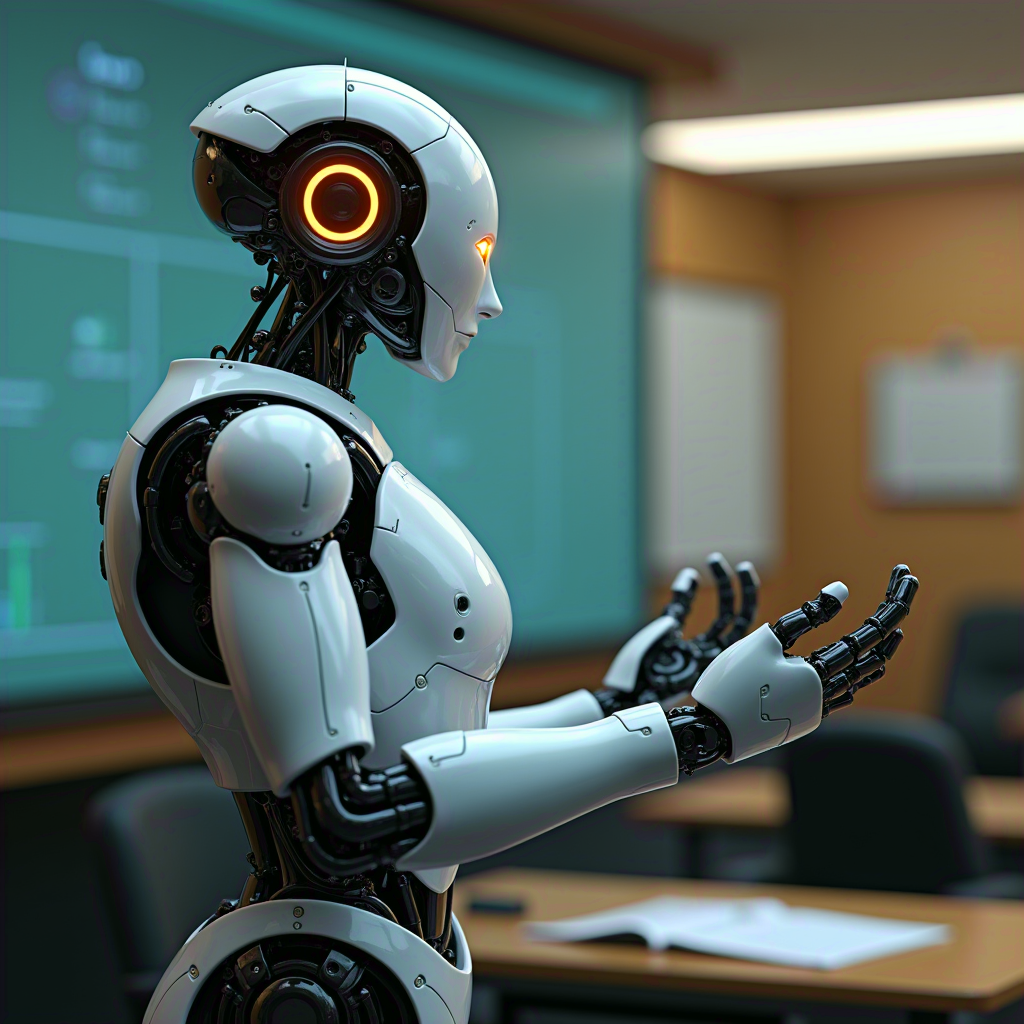

In [5]:
import base64
import pandas as pd
from IPython.display import Image as IPImage, display

def generate_and_display(prompt: str) -> None:
    """Generate an image and display it inline in the notebook."""
    print(f"Generating: '{prompt[:60]}...'")
    t0 = __import__('time').time()

    result = model.predict(pd.DataFrame([{"prompt": prompt}]))
    elapsed = __import__('time').time() - t0
    answer = result["answer"].iloc[0]

    # Latent-token proxy: 512×512 image → 64×64 latent → 4,096 patches (16-px patch size)
    monitor.log_inference(num_tokens=512 * 512 // 64, elapsed_seconds=elapsed)

    if len(answer) > 200 and not answer.startswith("❌"):
        img_bytes = base64.b64decode(answer)
        print(f"✅ Generated in {elapsed:.1f}s")
        display(IPImage(data=img_bytes, width=512))
    else:
        print(f"Error: {answer}")

# First generation — this also loads the pipeline into VRAM
generate_and_display(
    "A futuristic AI robot teaching in a university classroom, photorealistic, warm lighting, high detail"
)


Generating: 'Abstract visualization of a neural network, glowing blue nod...'


  0%|          | 0/28 [00:00<?, ?it/s]

✅ Generated in 82.7s


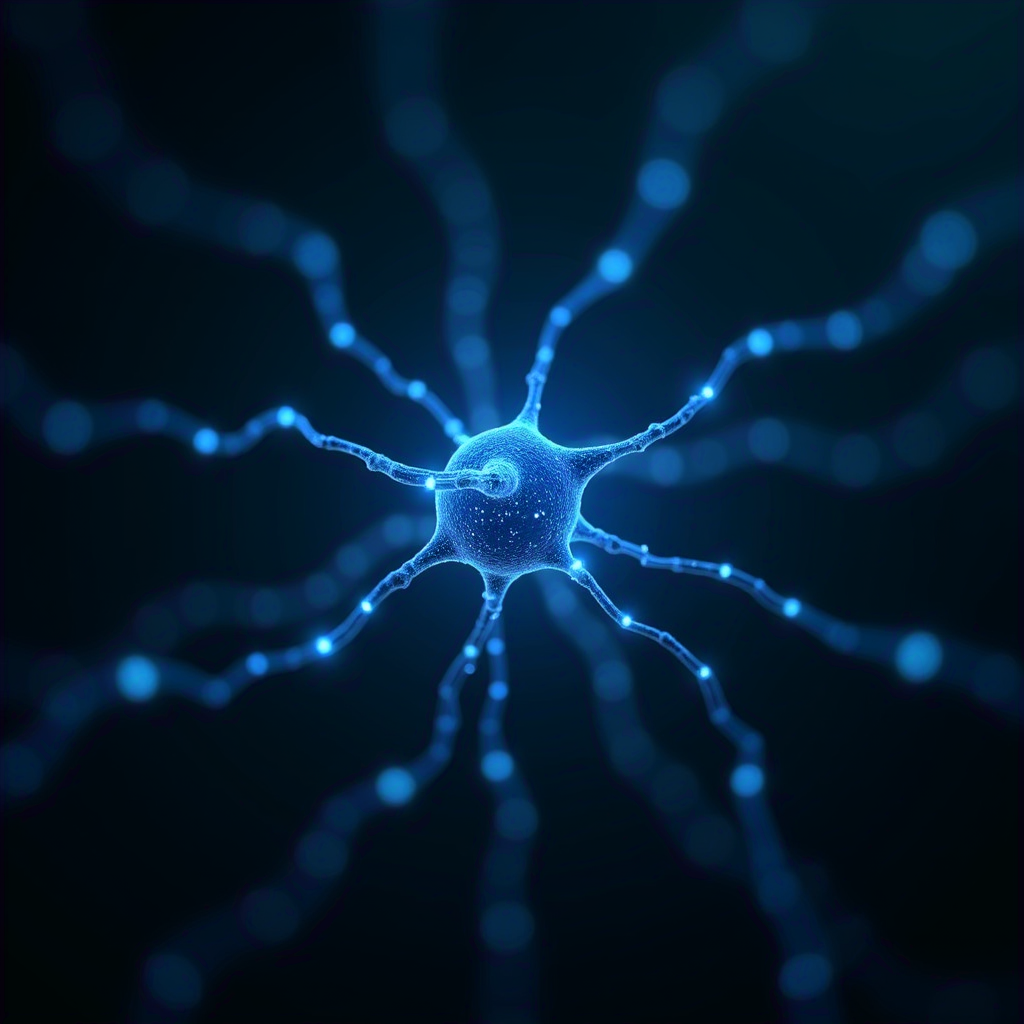

In [6]:
# Second generation — pipeline already in VRAM, much faster
generate_and_display(
    "Abstract visualization of a neural network, glowing blue nodes and connections, dark background, digital art"
)

In [7]:
import time
import plotly.graph_objects as go

# Measure generation time across multiple prompts (pipeline already warm)
bench_prompts = [
    "A scenic mountain landscape at sunrise",
    "Abstract data visualization with colorful charts",
    "A circuit board with glowing components, macro photography",
]

times = []
for p in bench_prompts:
    t0 = time.time()
    res = model.predict(pd.DataFrame([{"prompt": p}]))
    elapsed = time.time() - t0
    times.append(elapsed)
    monitor.log_inference(num_tokens=512 * 512 // 64, elapsed_seconds=elapsed)

fig = go.Figure(go.Bar(
    x=[f"Prompt {i+1}" for i in range(len(bench_prompts))],
    y=times,
    marker_color="#0096d6",
    text=[f"{t:.1f}s" for t in times],
    textposition="auto",
))
fig.update_layout(
    title="Image Generation Time per Prompt",
    xaxis_title="Prompt",
    yaxis_title="Time (seconds)",
    template="plotly_white",
)
fig.show()


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

## 6. GPU Monitoring

FLUX.1-dev uses significantly more VRAM than the chatbot (GGUF transformer + text encoders + VAE loaded).
Observe how the diffusion pipeline occupies GPU memory.

In [8]:
monitor.display_dashboard()


## 7. Register with MLflow

Register this model as **`AIStudio-EQ-ImageGen`**. 

The `configs/image_gen.yaml` has `capability: image_gen` so `loader.py` will
automatically select `ImageGenModel` when this registered model is loaded or served.

In [9]:
import mlflow

EXPERIMENT_NAME = 'ImageGeneration-StarterExperiment'

mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "/phoenix/mlflow"))
mlflow.set_experiment(experiment_name= EXPERIMENT_NAME)

ARTIFACT_PATH = "AIStudio-EQ-ImageGen"
MODEL_NAME    = "AIStudio-EQ-ImageGen"

print(f"Artifact path  : {ARTIFACT_PATH}")
print(f"Registered as  : {MODEL_NAME}")
print(f"Tracking URI   : {mlflow.get_tracking_uri()}")

Artifact path  : AIStudio-EQ-ImageGen
Registered as  : AIStudio-EQ-ImageGen
Tracking URI   : /phoenix/mlflow


In [10]:
from mlflow.models import ModelSignature
from mlflow.types.schema import ColSpec, Schema

# Minimal input schema: ImageGenModel only needs the prompt
input_schema = Schema([
    ColSpec("string", "prompt"),   # Text description of the image
])

output_schema = Schema([
    ColSpec("string", "answer"),    # Base64-encoded PNG image
    ColSpec("string", "messages"),  # JSON metadata
])

signature = ModelSignature(inputs=input_schema, outputs=output_schema)

print("Input  :", signature.inputs.to_dict())
print("Output :", signature.outputs.to_dict())


Input  : [{'type': 'string', 'name': 'prompt', 'required': True}]
Output : [{'type': 'string', 'name': 'answer', 'required': True}, {'type': 'string', 'name': 'messages', 'required': True}]


In [11]:
from src.mlflow.logger import Logger

print(f"✅ Registering Model  : {MODEL_NAME}")

with mlflow.start_run(run_name=f"register-{ARTIFACT_PATH}") as run:
    Logger.log_model(
        signature     = signature,
        artifact_path = ARTIFACT_PATH,
        config_path   = "../configs/image_gen.yaml",
        model_path    = image_model_path,
        demo_folder   = "../demo/image_gen",
    )
    run_id = run.info.run_id

print(f"✅ Model logged | Run ID: {run_id}")

model_uri = f"runs:/{run_id}/{ARTIFACT_PATH}"
reg = mlflow.register_model(model_uri=model_uri, name=MODEL_NAME)

print(f"✅ Registered  : {MODEL_NAME} v{reg.version}")


✅ Registering Model  : AIStudio-EQ-ImageGen


/opt/conda/lib/python3.12/site-packages/mlflow/pyfunc/__init__.py:3262: UserWarning:

An input example was not provided when logging the model. To ensure the model signature functions correctly, specify the `input_example` parameter. See https://mlflow.org/docs/latest/model/signatures.html#model-input-example for more details about the benefits of using input_example.

Registered model 'AIStudio-EQ-ImageGen' already exists. Creating a new version of this model...
2026/02/27 18:11:08 WARNING mlflow.tracking._model_registry.fluent: Run with id 8b96db53399e4adcb73a92d8b40c2f8f has no artifacts at artifact path 'AIStudio-EQ-ImageGen', registering model based on models:/m-cbfd943f4543421cbd1da0529bc90f1b instead


✅ Model logged | Run ID: 8b96db53399e4adcb73a92d8b40c2f8f
✅ Registered  : AIStudio-EQ-ImageGen v23


Created version '23' of model 'AIStudio-EQ-ImageGen'.


## 8. Verify Registration

Load the registered model and confirm it generates an image successfully.

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

✅ Registered model generated an image successfully


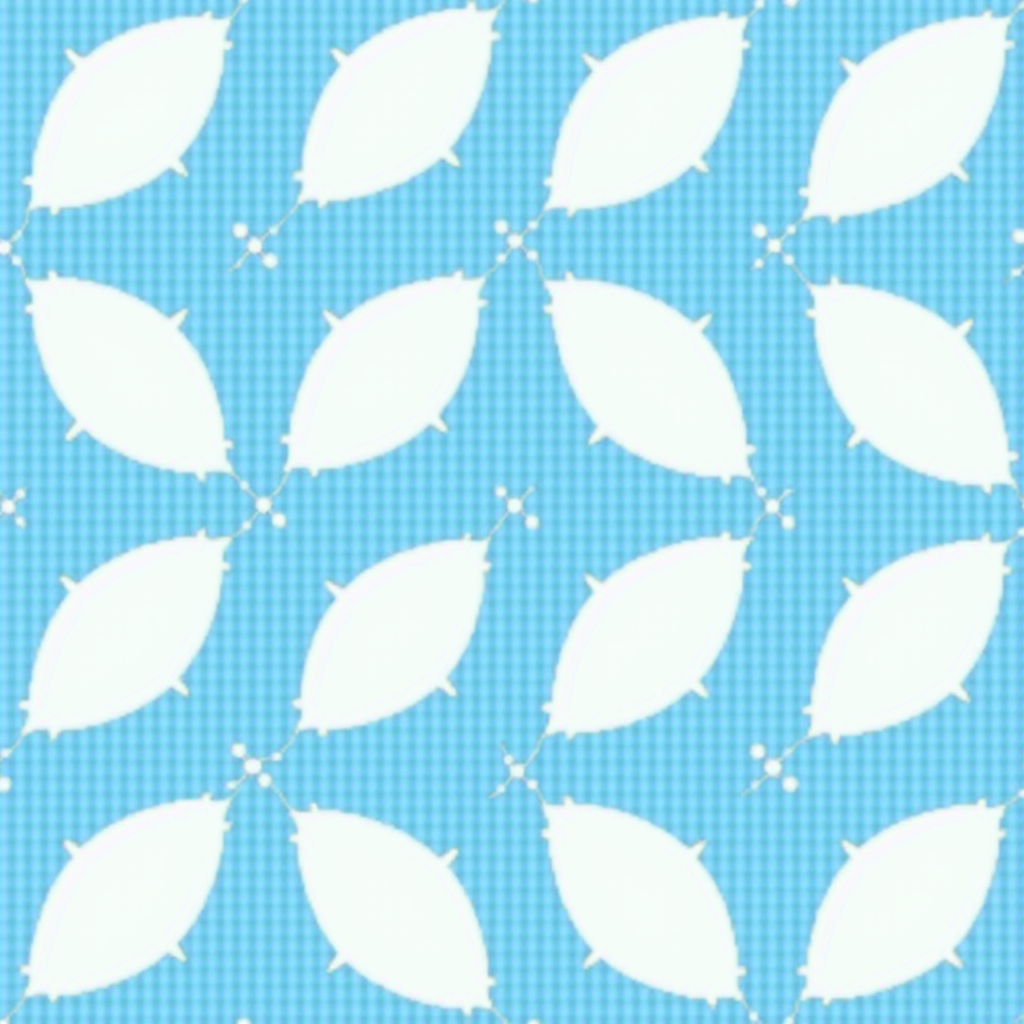

In [12]:
loaded_model = mlflow.pyfunc.load_model(model_uri=model_uri)

test_result = loaded_model.predict(pd.DataFrame([{
    "prompt": "A simple geometric pattern, blue and white, minimalist"
}]))

answer = test_result["answer"].iloc[0]
if len(answer) > 200 and not answer.startswith("❌"):
    img_bytes = base64.b64decode(answer)
    print("✅ Registered model generated an image successfully")
    display(IPImage(data=img_bytes, width=256))
else:
    print(f"Response: {answer}")

In [13]:
elapsed = time.time() - start_time
print(f"⏱️  Total notebook time: {elapsed:.1f}s ({elapsed / 60:.1f} min)")

⏱️  Total notebook time: 676.6s (11.3 min)


---

## ✅ What We Accomplished

| Step | Result |
|------|--------|
| Environment | CUDA verified, VRAM checked |
| ImageGenModel | Initialized with FLUX.1-dev GGUF (lazy pipeline loading) |
| Demo | Generated and displayed multiple images inline |
| GPU Monitor | VRAM usage during diffusion visible |
| Registration | `AIStudio-EQ-ImageGen` registered in Model Registry |
| Verification | Loaded model generated test image |

## Next Steps

- **Explore another capability:** Open `document-analyzer-starter.ipynb`
- **Deploy in AI Studio:** Select `AIStudio-EQ-ImageGen` → click Deploy → use the image gen Streamlit UI
- **Try different prompts:** Experiment with style keywords: `photorealistic`, `oil painting`, `watercolor`, `digital art`
- **Adjust quality vs. speed:** Edit `num_inference_steps` in `ImageGenModel._generate()` (1–8 steps)